Given a dataset with multiple features, implement a Genetic Algorithm (GA) to select the most relevant features for a classification model (e.g., Decision Tree, SVM) that maximizes model accuracy based on the task given below.
- Represent each feature subset as a chromosome (binary vector where 1 indicates inclusion and 0 indicates exclusion of features).
- Define a fitness function based on the model accuracy (higher accuracy means higher fitness).
- Apply selection, crossover, and mutation to evolve the feature subsets.
- Train the classification model using the selected features and evaluate its accuracy.
- Output the best feature subset and the corresponding accuracy.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# 1. LOAD DATA (13 Attributes)
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
n_feat = X.shape[1]

In [3]:
# 2. GA SETTINGS
pop_size = 10
gens = 12
mut_rate = 0.1

In [ ]:
# Initialize Population (Random 1s and 0s)
pop = np.random.randint(2, size=(pop_size, n_feat))
history = []

In [5]:
best_score = 0
best_chromosome = None

In [6]:
# 3. EVOLUTION LOOP
for g in range(gens):
    scores = []

    for chrom in pop:
        # Active features
        idx = [i for i, bit in enumerate(chrom) if bit == 1]

        # Skip empty feature set
        if not idx:
            scores.append(0)
            continue

        # Train/Test Split
        xt, xv, yt, yv = train_test_split(
            X.iloc[:, idx],
            y,
            test_size=0.30,
            random_state=42
        )

        # Random Forest Classifier
        model = RandomForestClassifier(n_estimators=10, random_state=42)

        model.fit(xt, yt)
        pred = model.predict(xv)
        acc = accuracy_score(yv, pred)
        scores.append(acc)

    # Store best chromosome found so far
    gen_best_idx = np.argmax(scores)

    if scores[gen_best_idx] > best_score:
        best_score = scores[gen_best_idx]
        best_chromosome = pop[gen_best_idx].copy()

    history.append(max(scores))

    # Selection
    parents = pop[
        np.argsort(scores)[-pop_size // 2:]
    ]

    # Crossover + Mutation
    new_pop = []

    for _ in range(pop_size):

        p1 = parents[np.random.randint(len(parents))]
        p2 = parents[np.random.randint(len(parents))]

        # Uniform Crossover
        child = np.array([p1[i]
            if np.random.rand() > 0.5
            else p2[i]
            for i in range(n_feat)
        ])

        # Mutation
        if np.random.rand() < mut_rate:
            m_idx = np.random.randint(n_feat)
            child[m_idx] = 1 - child[m_idx]

        new_pop.append(child)

    pop = np.array(new_pop)

    print(
        f"Gen {g+1}: Best Accuracy = {max(scores):.4f}"
    )

Gen 1: Best Accuracy = 0.9815
Gen 2: Best Accuracy = 0.9815
Gen 3: Best Accuracy = 0.9815
Gen 4: Best Accuracy = 0.9815
Gen 5: Best Accuracy = 0.9815
Gen 6: Best Accuracy = 0.9815
Gen 7: Best Accuracy = 1.0000
Gen 8: Best Accuracy = 1.0000
Gen 9: Best Accuracy = 0.9815
Gen 10: Best Accuracy = 0.9815
Gen 11: Best Accuracy = 0.9815
Gen 12: Best Accuracy = 0.9815


In [7]:
# 4. FINAL RESULTS
best_idx = [
    i
    for i, bit in enumerate(best_chromosome)
    if bit == 1
]

print("\n--- FINAL RECOMMENDATION ---")
print(
    f"Attributes Selected: {len(best_idx)} out of {n_feat}"
)

print(
    f"Features: {list(X.columns[best_idx])}"
)

print(
    f"Best Accuracy: {best_score:.4f}"
)



--- FINAL RECOMMENDATION ---
Attributes Selected: 7 out of 13
Features: ['magnesium', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Best Accuracy: 1.0000


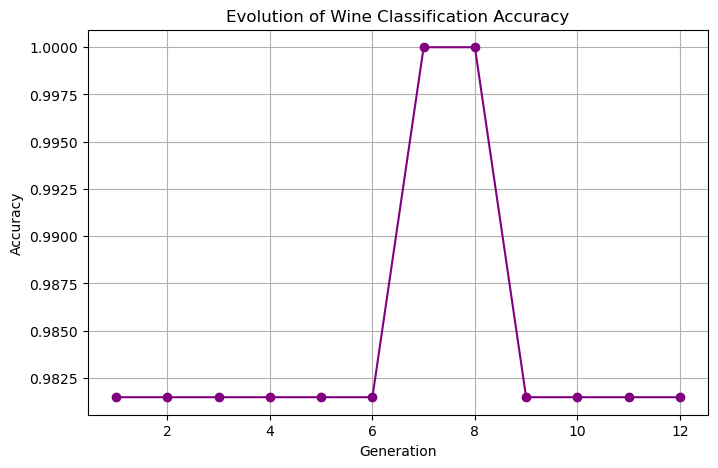

In [9]:
# 5. VISUALIZATION
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, gens + 1),
    history,
    marker='o',
    color='purple'
)

plt.title(
    "Evolution of Wine Classification Accuracy"
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Generation 1: 1.0000
Generation 2: 1.0000
Generation 3: 0.9815
Generation 4: 1.0000
Generation 5: 1.0000
Generation 6: 0.9815
Generation 7: 0.9815
Generation 8: 0.9815
Generation 9: 1.0000
Generation 10: 1.0000
Generation 11: 0.9815
Generation 12: 0.9815

Best Feature Subset:
[1 0 0 0 1 0 1 1 0 1 1 1 1]
Best Accuracy:
1.0


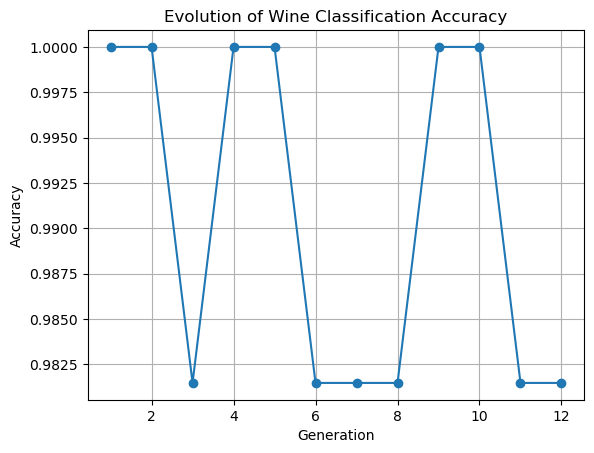

In [39]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target

num_features = X.shape[1]

best_accuracy = 0
history = []

# 12 Generations
for generation in range(12):

    generation_best = 0

    # Test 10 random feature subsets
    for i in range(10):

        chromosome = np.random.randint(0, 2, num_features)

        selected_features = X[:, chromosome == 1]

        if selected_features.shape[1] == 0:
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            selected_features,
            y,
            test_size=0.3,
            random_state=42
        )

        model = RandomForestClassifier()
        model.fit(X_train, y_train)

        accuracy = model.score(X_test, y_test)

        generation_best = max(generation_best, accuracy)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_chromosome = chromosome

    history.append(generation_best)

    print(
        f"Generation {generation+1}: {generation_best:.4f}"
    )

print("\nBest Feature Subset:")
print(best_chromosome)

print("Best Accuracy:")
print(best_accuracy)

# Evolution Graph
plt.plot(range(1, 13), history, marker='o')
plt.title("Evolution of Wine Classification Accuracy")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()